In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, least_squares
from scipy.ndimage import gaussian_filter1d
from scipy.special import gamma as gamma_function


In [ ]:
from pathlib import Path
# Original input file
input_file = "Book2_fixed.csv"
# Read the original file
df = pd.read_csv(input_file)
# Extract the filename without ".csv"
input_path = Path(input_file)
base_name = input_path.stem
#fwhm, area, peak, position
# Use first two columns: Binding Energy and Intensity
x_original = df.iloc[:, 4].to_numpy(dtype=float)
y_original = df.iloc[:, 5].to_numpy(dtype=float)

GENERATE BACKGROUND

In [3]:
def auto_shirley_window(
    x,
    y,
    smooth_fraction=0.04,
    threshold_fraction=0.015,
    pad_fraction=0.06,
):
    """
    Propose a Shirley window around the detected peak envelope.

    The returned endpoints should be inspected manually before
    quantitative analysis.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    n = len(y_sorted)

    window = max(5, int(round(n * smooth_fraction)))

    if window % 2 == 0:
        window += 1

    largest_odd_window = n if n % 2 == 1 else n - 1
    window = min(window, largest_odd_window)

    half_window = window // 2
    kernel = np.ones(window, dtype=float) / window

    # Avoid zero-padding artifacts at the two data boundaries.
    y_padded = np.pad(
        y_sorted,
        pad_width=half_window,
        mode="edge"
    )

    y_smooth = np.convolve(
        y_padded,
        kernel,
        mode="valid"
    )

    edge_points = max(3, int(round(n * 0.08)))

    y_lowBE = np.median(y_smooth[:edge_points])
    y_highBE = np.median(y_smooth[-edge_points:])

    rough_baseline = np.linspace(
        y_lowBE,
        y_highBE,
        n
    )

    residual = y_smooth - rough_baseline
    positive_residual = np.maximum(residual, 0.0)

    residual_max = np.max(positive_residual)

    if residual_max <= 0:
        return float(x_sorted[0]), float(x_sorted[-1])

    active = np.flatnonzero(
        positive_residual
        > threshold_fraction * residual_max
    )

    if len(active) == 0:
        peak_index = int(np.argmax(positive_residual))
        active = np.array([peak_index])

    pad_points = max(2, int(round(n * pad_fraction)))

    left = max(0, active[0] - pad_points)
    right = min(n - 1, active[-1] + pad_points)

    return float(x_sorted[left]), float(x_sorted[right])

In [4]:
def shirley_background(
    x,
    y,
    fit_min=None,
    fit_max=None,
    endpoint_points=5,
    max_iter=500,
    rtol=1e-8,
    atol=1e-6,
):
    """
    Calculate a classic iterative Shirley background over a limited
    near-peak XPS energy range.

    Parameters
    ----------
    x : array-like
        Binding energy values.
    y : array-like
        Intensity values, preferably corrected for analyzer transmission.
    fit_min, fit_max : float, optional
        Binding-energy limits of the Shirley region.
    endpoint_points : int
        Number of points used to estimate each endpoint intensity.
    max_iter : int
        Maximum number of Shirley iterations.
    rtol, atol : float
        Relative and absolute convergence tolerances.

    Returns
    -------
    background : ndarray
        Shirley background in the original data order. Values outside
        the selected range are NaN.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if x.ndim != 1 or y.ndim != 1:
        raise ValueError("x and y must be one-dimensional arrays.")

    if len(x) != len(y):
        raise ValueError("x and y must have the same length.")

    if len(x) < 3:
        raise ValueError("At least three data points are required.")

    if not np.all(np.isfinite(x)) or not np.all(np.isfinite(y)):
        raise ValueError("x and y must contain only finite values.")

    # Sort from low binding energy to high binding energy.
    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    # Duplicate energy values make integration ambiguous.
    if np.any(np.diff(x_sorted) <= 0):
        raise ValueError("Binding-energy values must be unique.")

    if fit_min is None:
        fit_min = float(x_sorted[0])

    if fit_max is None:
        fit_max = float(x_sorted[-1])

    fit_min, fit_max = sorted((float(fit_min), float(fit_max)))

    fit_mask = (x_sorted >= fit_min) & (x_sorted <= fit_max)

    if np.count_nonzero(fit_mask) < 3:
        raise ValueError(
            "The Shirley fit range must contain at least three points."
        )

    x_fit = x_sorted[fit_mask]
    y_fit = y_sorted[fit_mask]

    n_endpoint = min(
        int(endpoint_points),
        max(1, len(y_fit) // 4)
    )

    # Median endpoint levels reduce sensitivity to individual noisy points.
    y_lowBE = float(np.median(y_fit[:n_endpoint]))
    y_highBE = float(np.median(y_fit[-n_endpoint:]))

    # Initial approximation.
    bg = np.full_like(y_fit, y_lowBE, dtype=float)

    converged = False

    for iteration in range(1, max_iter + 1):
        bg_old = bg.copy()

        # Do not clip negative values; retain the iterative Shirley equation.
        net = y_fit - bg_old

        # Cumulative trapezoidal integral from low BE to high BE.
        dx = np.diff(x_fit)
        trapezoids = 0.5 * (net[:-1] + net[1:]) * dx

        cumulative_area = np.concatenate(
            ([0.0], np.cumsum(trapezoids))
        )

        total_area = cumulative_area[-1]

        if (
            not np.isfinite(total_area)
            or abs(total_area) < np.finfo(float).eps
        ):
            raise RuntimeError(
                "The net Shirley area is zero or non-finite. "
                "Check the selected endpoints."
            )

        bg = (
            y_lowBE
            + (y_highBE - y_lowBE)
            * cumulative_area
            / total_area
        )

        if np.allclose(bg, bg_old, rtol=rtol, atol=atol):
            converged = True
            print(f"Converged after {iteration} iterations")
            break

    if not converged:
        raise RuntimeError(
            f"Shirley background did not converge after "
            f"{max_iter} iterations."
        )

    bg_sorted = np.full(y_sorted.shape, np.nan, dtype=float)
    bg_sorted[fit_mask] = bg

    background = np.empty_like(bg_sorted)
    background[order] = bg_sorted

    return background

In [5]:
# Only divide by transmission if Count/s has not already been corrected.
y_for_analysis = y_original
# y_for_analysis = count_per_second / transmission

SHIRLEY_MIN_BE, SHIRLEY_MAX_BE = auto_shirley_window(
    x_original,
    y_for_analysis
)

print(
    f"Proposed Shirley window: "
    f"{SHIRLEY_MIN_BE:.2f} to {SHIRLEY_MAX_BE:.2f} eV"
)

shirley = shirley_background(
    x_original,
    y_for_analysis,
    fit_min=SHIRLEY_MIN_BE,
    fit_max=SHIRLEY_MAX_BE,
    endpoint_points=5
)

corrected = y_for_analysis - shirley

Proposed Shirley window: 200.48 to 213.18 eV
Converged after 7 iterations


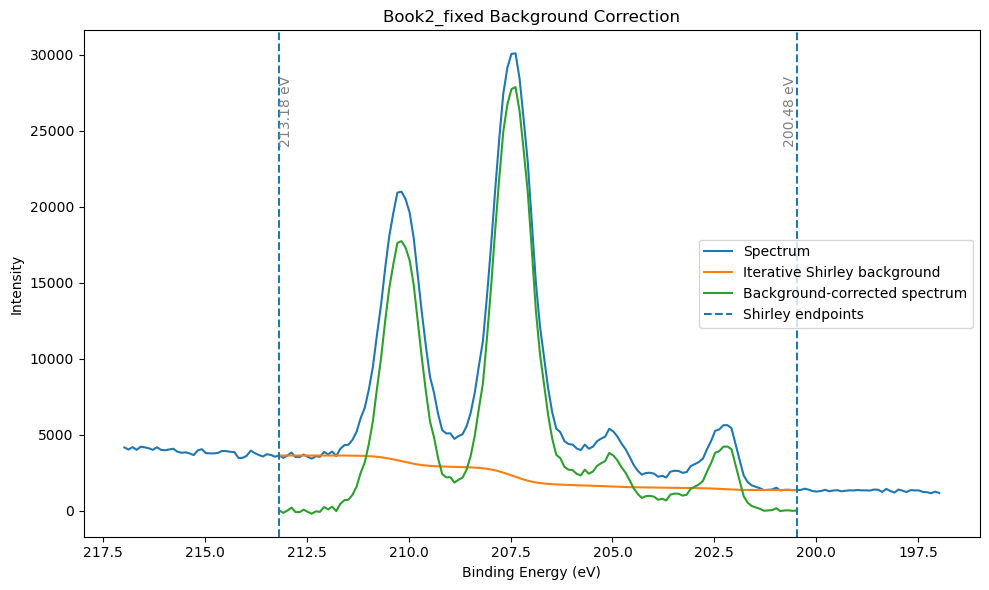

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    x_original,
    y_for_analysis,
    label="Spectrum"
)

plt.plot(
    x_original,
    shirley,
    label="Iterative Shirley background"
)

plt.plot(
    x_original,
    corrected,
    label="Background-corrected spectrum"
)

plt.axvline(
    SHIRLEY_MIN_BE,
    linestyle="--",
    label="Shirley endpoints"
)

plt.axvline(
    SHIRLEY_MAX_BE,
    linestyle="--"
)

y_top = np.max(y_original)

plt.text(SHIRLEY_MIN_BE, y_top * 0.95, f"{SHIRLEY_MIN_BE:.2f} eV",
         rotation=90, va="top", ha="right", fontsize=10, color="gray")

plt.text(SHIRLEY_MAX_BE, y_top * 0.95, f"{SHIRLEY_MAX_BE:.2f} eV",
         rotation=90, va="top", ha="left", fontsize=10, color="gray")
plt.title(f"{base_name} Background Correction")
plt.xlabel("Binding Energy (eV)")
plt.ylabel("Intensity")
plt.gca().invert_xaxis()
plt.legend()
plt.tight_layout()
plt.show()

FITTING

In [7]:
x = x_original
y = corrected

In [8]:
# Only fit finite points in the Nb 3d Shirley region.
mask = (
    (x >= SHIRLEY_MIN_BE)
    & (x <= SHIRLEY_MAX_BE)
    & np.isfinite(x)
    & np.isfinite(y)
)
x = x[mask]
y = y[mask]

# Sort from low to high binding energy.
order = np.argsort(x)
x = x[order]
y = y[order]

# IMPORTANT: do not shift y by subtracting its minimum.
# A vertical shift adds artificial area to every fitted component.


## Area-parameterized peak model

The fitting functions below use **integrated area**, rather than peak height, as their fitted amplitude parameter. Therefore, the fitted area of each chemical-state doublet is read directly from `popt`; no Simpson, trapezoidal, or reference-area calibration is used.

The oxide pseudo-Voigt profiles are normalized analytically over the full curve. The asymmetric metallic profile is also normalized analytically before Gaussian broadening; convolution with a normalized Gaussian preserves area. The fixed 3d5/2:3d3/2 area ratio is 3:2, so 60% of each doublet area belongs to 3d5/2 and 40% to 3d3/2.


In [9]:
def pseudo_voigt_unit_area(x, center, fwhm, eta):
    """Pseudo-Voigt profile analytically normalized to unit full area."""
    x = np.asarray(x, dtype=float)
    sigma = fwhm / 2.35482

    gaussian = np.exp(-((x - center) ** 2) / (2 * sigma ** 2))
    lorentzian = 1.0 / (1.0 + 4.0 * ((x - center) / fwhm) ** 2)

    # Exact full-domain areas of the height-one Gaussian and Lorentzian.
    gaussian_area = sigma * np.sqrt(2.0 * np.pi)
    lorentzian_area = np.pi * fwhm / 2.0
    normalization = (1.0 - eta) * gaussian_area + eta * lorentzian_area

    return ((1.0 - eta) * gaussian + eta * lorentzian) / normalization


def pseudo_voigt(x, area, center, fwhm, eta):
    """Pseudo-Voigt whose `area` parameter is its exact full integrated area."""
    return area * pseudo_voigt_unit_area(x, center, fwhm, eta)


In [10]:
def estimate_peak_fwhm(x, y, center_guess):
    """Estimate the FWHM of a local peak from the data near a guessed center."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 3:
        return np.nan

    peak_idx = int(np.argmin(np.abs(x - center_guess)))
    peak_height = float(y[peak_idx])

    if not np.isfinite(peak_height) or peak_height <= 0:
        return np.nan

    half_height = peak_height / 2.0

    left_mask = (x <= x[peak_idx]) & (y <= half_height)
    right_mask = (x >= x[peak_idx]) & (y <= half_height)

    left_candidates = np.flatnonzero(left_mask)
    right_candidates = np.flatnonzero(right_mask)

    if left_candidates.size == 0 or right_candidates.size == 0:
        return np.nan

    left_idx = left_candidates[-1]
    right_idx = right_candidates[0]

    if left_idx == right_idx:
        return np.nan

    if left_idx + 1 < len(x):
        left_x = np.interp(
            half_height,
            [y[left_idx], y[left_idx + 1]],
            [x[left_idx], x[left_idx + 1]],
        )
    else:
        left_x = x[left_idx]

    if right_idx - 1 >= 0:
        right_x = np.interp(
            half_height,
            [y[right_idx - 1], y[right_idx]],
            [x[right_idx - 1], x[right_idx]],
        )
    else:
        right_x = x[right_idx]

    return float(abs(right_x - left_x))


In [11]:
SPLIT = 2.72
RATIO = 2 / 3  # 3d3/2 area relative to 3d5/2


def split_doublet_area(total_area, ratio=RATIO):
    """Return the exact 3d5/2 and 3d3/2 areas for a fixed area ratio."""
    area_5_2 = total_area / (1.0 + ratio)
    area_3_2 = total_area - area_5_2
    return area_5_2, area_3_2


def pseudo_voigt_doublet(x, total_area, center_5_2, fwhm, eta,
                          split=SPLIT, ratio=RATIO):
    """Area-parameterized pseudo-Voigt doublet."""
    area_5_2, area_3_2 = split_doublet_area(total_area, ratio)
    p_5_2 = pseudo_voigt(x, area_5_2, center_5_2, fwhm, eta)
    p_3_2 = pseudo_voigt(x, area_3_2, center_5_2 + split, fwhm, eta)
    return p_5_2 + p_3_2


def oxide_doublet(x, total_area, center_5_2, fwhm, eta):
    return pseudo_voigt_doublet(x, total_area, center_5_2, fwhm, eta)


'def metal_doublet(x, height, center_5_2, fwhm, eta=0.25):\n    """Metallic Nb 3d doublet using a pseudo-Voigt line shape."""\n    return pseudo_voigt_doublet(x, height, center_5_2, fwhm, eta)'

In [12]:
SPLIT = 2.72
RATIO = 2 / 3

# This factor converts the internal asymmetric-width parameter to the
# reported metallic FWHM. It does NOT alter any fitted area.
METAL_FWHM_CALIBRATION = np.mean([
    0.81600 / 1.72100,
    0.63663 / 1.34900,
    0.60 / 1.287,
    0.58 / 1.252,
    0.59 / 1.256,
    0.55 / 1.125,
    0.57 / 1.225,
])


def metal_internal_to_fwhm(internal_width):
    return float(internal_width) * METAL_FWHM_CALIBRATION


def metal_fwhm_to_internal(fwhm):
    return float(fwhm) / METAL_FWHM_CALIBRATION


def asymmetric_la_unit_area(x, center, internal_width,
                            alpha=1.2, beta=5.0, m=12.0):
    """
    Asymmetric LA-like profile with exact analytical area normalization.

    The unsmoothed left and right branches are powers of a Lorentzian.
    Their full-domain integrals are evaluated with Gamma functions.
    Gaussian broadening uses a normalized kernel and therefore preserves area.
    """
    x = np.asarray(x, dtype=float)
    gamma_l = internal_width / 2.0
    u = (x - center) / gamma_l
    lorentzian = 1.0 / (1.0 + u ** 2)

    profile = np.empty_like(x, dtype=float)
    low_be = x <= center
    profile[low_be] = lorentzian[low_be] ** beta
    profile[~low_be] = lorentzian[~low_be] ** alpha

    def half_line_power_area(power):
        if power <= 0.5:
            raise ValueError('LA exponent must be greater than 0.5.')
        return (
            gamma_l * np.sqrt(np.pi)
            * gamma_function(power - 0.5)
            / (2.0 * gamma_function(power))
        )

    exact_unsmoothed_area = (
        half_line_power_area(beta) + half_line_power_area(alpha)
    )
    profile = profile / exact_unsmoothed_area

    if m > 0 and len(x) > 1:
        dx = float(np.median(np.diff(np.sort(x))))
        if dx <= 0 or not np.isfinite(dx):
            raise ValueError('x must contain unique finite values.')
        # Preserve the notebook's original broadening convention while
        # applying a normalized Gaussian convolution.
        sigma_points = m / 10.0
        profile = gaussian_filter1d(profile, sigma=sigma_points, mode='constant')

    return profile


def LA_peak(x, area, center, internal_width, alpha=1.2, beta=5, m=12):
    """Asymmetric LA-like peak whose `area` parameter is the full area."""
    return area * asymmetric_la_unit_area(
        x, center, internal_width, alpha=alpha, beta=beta, m=m
    )


def metal_doublet(x, total_area, center_5_2, internal_width):
    area_5_2, area_3_2 = split_doublet_area(total_area)
    p_5_2 = LA_peak(x, area_5_2, center_5_2, internal_width)
    p_3_2 = LA_peak(x, area_3_2, center_5_2 + SPLIT, internal_width)
    return p_5_2 + p_3_2

print(f'Metal FWHM reporting factor = {METAL_FWHM_CALIBRATION:.6f}')


Metal FWHM calibration factor = 0.471353


In [13]:
def total_model(x,
                area_m, be_m, metal_internal_width,
                fwhm_ox,
                area_nbo, be_nbo, eta_nbo,
                area_nbo2, be_nbo2, eta_nbo2,
                area_nb2o5, be_nb2o5, eta_nb2o5):
    return (
        metal_doublet(x, area_m, be_m, metal_internal_width)
        + oxide_doublet(x, area_nbo, be_nbo, fwhm_ox, eta_nbo)
        + oxide_doublet(x, area_nbo2, be_nbo2, fwhm_ox, eta_nbo2)
        + oxide_doublet(x, area_nb2o5, be_nb2o5, fwhm_ox, eta_nb2o5)
    )


def exact_piecewise_linear_area(x_values, y_values):
    """
    Exact integral of the piecewise-linear curve through the supplied points.
    This evaluates each line segment analytically; it does not call Simpson
    or a trapezoidal integration routine.
    """
    xv = np.asarray(x_values, dtype=float)
    yv = np.asarray(y_values, dtype=float)
    valid = np.isfinite(xv) & np.isfinite(yv)
    xv, yv = xv[valid], yv[valid]
    order = np.argsort(xv)
    xv, yv = xv[order], yv[order]
    if len(xv) < 2:
        raise ValueError('At least two finite points are required.')
    dx = np.diff(xv)
    if np.any(dx <= 0):
        raise ValueError('x values must be unique.')
    # Exact antiderivative of the straight line joining each adjacent pair.
    return float(np.sum(dx * (yv[:-1] + yv[1:]) / 2.0))


# Use physically meaningful metal-FWHM guesses and bounds, then convert
# them to the internal width required by the asymmetric LA implementation.
metal_fwhm_guess = estimate_peak_fwhm(x, y, 202.2)
if not np.isfinite(metal_fwhm_guess) or metal_fwhm_guess <= 0:
    metal_fwhm_guess = 0.75
metal_fwhm_guess = float(np.clip(metal_fwhm_guess, 0.35, 1.20))
metal_internal_guess = metal_fwhm_to_internal(metal_fwhm_guess)
metal_internal_lower = metal_fwhm_to_internal(0.35)
metal_internal_upper = metal_fwhm_to_internal(1.20)

oxide_fwhm_guess = estimate_peak_fwhm(x, y, 207.4)
if not np.isfinite(oxide_fwhm_guess) or not (0.70 <= oxide_fwhm_guess <= 1.60):
    oxide_fwhm_guess = 1.12
oxide_fwhm_guess = float(np.clip(oxide_fwhm_guess, 0.85, 1.40))

CENTER_TARGETS = {
    'metal': 202.2,
    'nbo': 204.3,
    'nbo2': 206.12,
    'nb2o5': 207.70,
}
CENTER_STDS = {
    'metal': 0.30,
    'nbo': 0.65,
    'nbo2': 0.45,
    'nb2o5': 0.45,
}

# Estimate the corrected spectrum's total area only to build initial guesses.
# The final reported component areas come directly from fitted parameters.
initial_total_area = max(exact_piecewise_linear_area(x, np.maximum(y, 0.0)), 1.0)

p0 = [
    0.03 * initial_total_area, CENTER_TARGETS['metal'], metal_internal_guess,
    oxide_fwhm_guess,
    0.03 * initial_total_area, CENTER_TARGETS['nbo'], 0.30,
    0.12 * initial_total_area, CENTER_TARGETS['nbo2'], 0.30,
    0.82 * initial_total_area, CENTER_TARGETS['nb2o5'], 0.30,
]

lower = [
    0, CENTER_TARGETS['metal'] - CENTER_STDS['metal'], metal_internal_lower,
    0.85,
    0, CENTER_TARGETS['nbo'] - CENTER_STDS['nbo'], 0.0,
    0, CENTER_TARGETS['nbo2'] - CENTER_STDS['nbo2'], 0.0,
    0, CENTER_TARGETS['nb2o5'] - CENTER_STDS['nb2o5'], 0.0,
]

upper = [
    np.inf, CENTER_TARGETS['metal'] + CENTER_STDS['metal'], metal_internal_upper,
    1.40,
    np.inf, CENTER_TARGETS['nbo'] + CENTER_STDS['nbo'], 1.0,
    np.inf, CENTER_TARGETS['nbo2'] + CENTER_STDS['nbo2'], 1.0,
    np.inf, CENTER_TARGETS['nb2o5'] + CENTER_STDS['nb2o5'], 1.0,
]

print(f'Initial fitted-area estimate: {initial_total_area:.2f}')
print(f'Initial metal FWHM guess: {metal_fwhm_guess:.3f} eV')
print(f'Initial oxide FWHM guess: {oxide_fwhm_guess:.3f} eV')


Initial calibrated metal FWHM guess: 0.896 eV
Initial oxide FWHM guess: 1.183 eV


In [14]:
# Oxide FWHM is now fitted as popt[3], not fixed from a single peak estimate.


In [15]:
# x and y were already filtered, sorted, and baseline-shifted in the data-prep cell above.


In [16]:
p0 = np.asarray(p0, dtype=float)
lower = np.asarray(lower, dtype=float)
upper = np.asarray(upper, dtype=float)

if not (len(p0) == len(lower) == len(upper)):
    raise ValueError(
        f"p0, lower, and upper must have the same length; got "
        f"{len(p0)}, {len(lower)}, {len(upper)}."
    )

outside = np.where((p0 < lower) | (p0 > upper))[0]

if outside.size:
    print("The following initial guesses were outside their bounds:")
    for idx in outside:
        print(
            f"  index {idx}: p0={p0[idx]:.6g}, "
            f"lower={lower[idx]:.6g}, upper={upper[idx]:.6g}"
        )

    # Move any out-of-range starting values safely inside their bounds.
    finite_lower = np.isfinite(lower)
    finite_upper = np.isfinite(upper)

    p0[finite_lower] = np.maximum(
        p0[finite_lower],
        lower[finite_lower] + 1e-8
    )
    p0[finite_upper] = np.minimum(
        p0[finite_upper],
        upper[finite_upper] - 1e-8
    )

    print("Adjusted out-of-range p0 values to lie inside the bounds.")

if not np.all(np.isfinite(x)) or not np.all(np.isfinite(y)):
    raise ValueError("x and y must be finite before curve_fit.")


In [17]:
# Multi-start bounded fit: reduces sensitivity to one arbitrary p0.
rng = np.random.default_rng(42)
best = None

starts = [p0.copy()]
for _ in range(24):
    trial = p0.copy()
    # Randomize fitted areas over a broad but positive range.
    for idx in (0, 4, 7, 10):
        trial[idx] *= np.exp(rng.normal(0.0, 0.65))
    # Randomize centers and shape parameters within their bounds.
    for idx in (1, 2, 3, 5, 6, 8, 9, 11, 12):
        span = upper[idx] - lower[idx]
        trial[idx] = np.clip(
            trial[idx] + rng.normal(0.0, 0.12 * span),
            lower[idx] + 1e-8,
            upper[idx] - 1e-8,
        )
    starts.append(trial)

for start in starts:
    try:
        candidate, covariance = curve_fit(
            total_model,
            x,
            y,
            p0=start,
            bounds=(lower, upper),
            maxfev=500000,
            x_scale="jac",
        )
        residual = y - total_model(x, *candidate)
        score = float(np.mean(residual ** 2))
        if best is None or score < best[0]:
            best = (score, candidate, covariance)
    except (RuntimeError, ValueError, FloatingPointError):
        continue

if best is None:
    raise RuntimeError("All fitting starts failed. Inspect the Shirley window and input data.")

fit_mse, popt, pcov = best
print(f"Best multi-start MSE: {fit_mse:.6g}")


Best multi-start MSE: 46748.2


In [18]:
print("popt values:")
for i, value in enumerate(popt):
    print(f"popt[{i}] = {value}")

popt values:
popt[0] = 4399.447825997346
popt[1] = 202.1817172610649
popt[2] = 1.2834515499183006
popt[3] = 1.089003040467107
popt[4] = 729.4260829738412
popt[5] = 204.28653046638294
popt[6] = 0.9999999999971847
popt[7] = 1398.9140016401777
popt[8] = 206.04492905455658
popt[9] = 0.999999999982702
popt[10] = 27225.412191405703
popt[11] = 207.45818494134375
popt[12] = 0.097018371951832


In [19]:
nb_m = metal_doublet(x, popt[0], popt[1], popt[2])

oxide_fwhm = popt[3]

nbo = oxide_doublet(x, popt[4], popt[5], oxide_fwhm, popt[6])
nbo2 = oxide_doublet(x, popt[7], popt[8], oxide_fwhm, popt[9])
nb2o5 = oxide_doublet(x, popt[10], popt[11], oxide_fwhm, popt[12])


In [20]:
metal_center_5_2 = popt[1]
metal_fwhm = metal_internal_to_fwhm(popt[2])

nbo_center_5_2 = popt[5]
nbo2_center_5_2 = popt[8]
nb2o5_center_5_2 = popt[11]

print(f"\n{base_name} UNSHIFTED FIT RESULTS\n")

print(f"Nb metal 3d5/2: {metal_center_5_2:.3f} eV, FWHM = {metal_fwhm:.3f}")
print(f"NbO      3d5/2: {nbo_center_5_2:.3f} eV, FWHM = {oxide_fwhm:.3f}")
print(f"NbO2     3d5/2: {nbo2_center_5_2:.3f} eV, FWHM = {oxide_fwhm:.3f}")
print(f"Nb2O5    3d5/2: {nb2o5_center_5_2:.3f} eV, FWHM = {oxide_fwhm:.3f}")

print("\nFixed doublet separation = 2.72 eV")
print("Fixed area ratio 3d5/2 : 3d3/2 = 3 : 2")



Book2_fixed UNSHIFTED FIT RESULTS

Nb metal 3d5/2: 202.182 eV, FWHM = 0.605
NbO      3d5/2: 204.287 eV, FWHM = 1.089
NbO2     3d5/2: 206.045 eV, FWHM = 1.089
Nb2O5    3d5/2: 207.458 eV, FWHM = 1.089

Fixed doublet separation = 2.72 eV
Fixed area ratio 3d5/2 : 3d3/2 = 3 : 2


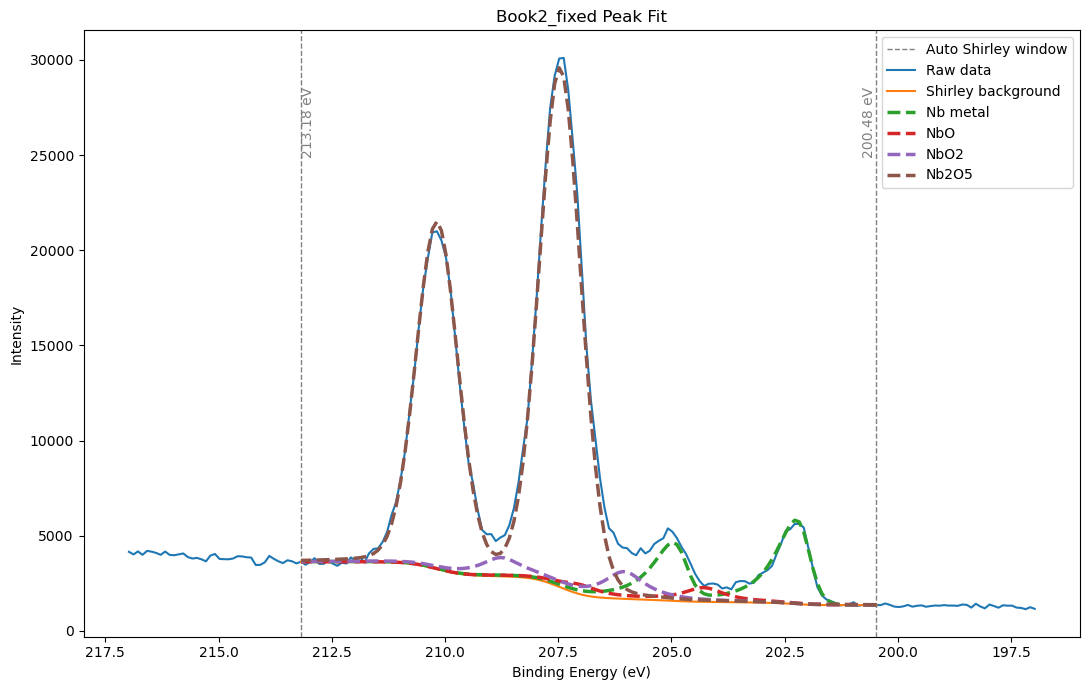

In [21]:
valid = np.isfinite(shirley)
order_bg = np.argsort(x_original[valid])

shirley_fit = np.interp(
    x,
    x_original[valid][order_bg],
    shirley[valid][order_bg]
)

plt.figure(figsize=(11, 7))

plt.axvline(SHIRLEY_MIN_BE, color="gray", linestyle="--", linewidth=1, label="Auto Shirley window")
plt.axvline(SHIRLEY_MAX_BE, color="gray", linestyle="--", linewidth=1)

plt.plot(x_original, y_original, label="Raw data", zorder=2)
plt.plot(x_original, shirley, label="Shirley background", zorder=3)

nb_m_fit = nb_m + shirley_fit
nbo_fit = nbo + shirley_fit
nbo2_fit = nbo2 + shirley_fit
nb2o5_fit = nb2o5 + shirley_fit

plt.plot(x, nb_m_fit, "--", linewidth=2.5, label="Nb metal", zorder=4)
plt.plot(x, nbo_fit, "--", linewidth=2.5, label="NbO", zorder=6)
plt.plot(x, nbo2_fit, "--", linewidth=2.5, label="NbO2", zorder=6)
plt.plot(x, nb2o5_fit, "--", linewidth=2.5, label="Nb2O5", zorder=6)



y_top = np.max(y_original)

plt.text(SHIRLEY_MIN_BE, y_top * 0.95, f"{SHIRLEY_MIN_BE:.2f} eV",
         rotation=90, va="top", ha="right", fontsize=10, color="gray")

plt.text(SHIRLEY_MAX_BE, y_top * 0.95, f"{SHIRLEY_MAX_BE:.2f} eV",
         rotation=90, va="top", ha="left", fontsize=10, color="gray")

plt.xlabel("Binding Energy (eV)")
plt.ylabel("Intensity")
plt.title(f"{base_name} Peak Fit")
plt.gca().invert_xaxis()
plt.legend()
plt.tight_layout()
plt.show()

## Exact raw fitted areas and Shirley-background area

Each chemical-state area is now a direct optimization parameter. The values in `popt[0]`, `popt[4]`, `popt[7]`, and `popt[10]` are the full doublet areas, so no numerical peak integration and no area-calibration factor are applied.

The Shirley background is a discrete curve. Its reported area is the exact integral of the piecewise-linear curve joining its calculated data points inside the Shirley window. This is evaluated segment by segment from the analytical line equation rather than through SciPy's Simpson or trapezoidal functions.


In [22]:
# ---------------------------------------------------------------------
# Raw fitted component areas: read directly from the fitted parameters.
# ---------------------------------------------------------------------
component_names = ['Nb metal', 'NbO', 'NbO2', 'Nb2O5']

raw_areas = np.array([
    popt[0],
    popt[4],
    popt[7],
    popt[10],
], dtype=float)

raw_total_fit_area = float(np.sum(raw_areas))

# Exact 3d5/2 and 3d3/2 allocations from the fixed 3:2 area ratio.
areas_5_2 = raw_areas / (1.0 + RATIO)
areas_3_2 = raw_areas - areas_5_2

# Shirley-background area over the actual Shirley points.
shirley_mask = (
    (x_original >= SHIRLEY_MIN_BE)
    & (x_original <= SHIRLEY_MAX_BE)
    & np.isfinite(x_original)
    & np.isfinite(shirley)
)
shirley_background_area = abs(exact_piecewise_linear_area(
    x_original[shirley_mask], shirley[shirley_mask]
))

# For comparison, the raw-spectrum and Shirley-corrected data areas are
# evaluated from the same piecewise-linear definition.
raw_spectrum_area = abs(exact_piecewise_linear_area(
    x_original[shirley_mask], y_for_analysis[shirley_mask]
))
shirley_corrected_data_area = abs(exact_piecewise_linear_area(
    x_original[shirley_mask], corrected[shirley_mask]
))

print(f'\n{base_name} RAW FITTED AREA SUMMARY\n')
print('The component areas below are direct fitted parameters;')
print('no area calibration and no numerical peak integration were used.\n')

for name, total_area, area_5_2, area_3_2 in zip(
    component_names, raw_areas, areas_5_2, areas_3_2
):
    print(f'{name:<8} = {total_area:.2f}  '
          f'(3d5/2 = {area_5_2:.2f}, 3d3/2 = {area_3_2:.2f})')

print('-' * 72)
print(f'Raw component sum          = {raw_total_fit_area:.2f}')
print(f'Shirley background area    = {shirley_background_area:.2f}')
print(f'Raw spectrum area          = {raw_spectrum_area:.2f}')
print(f'Shirley-corrected data area= {shirley_corrected_data_area:.2f}')
print(f'Raw - Shirley background   = '
      f'{raw_spectrum_area - shirley_background_area:.2f}')
print(f'Fit sum - corrected data   = '
      f'{raw_total_fit_area - shirley_corrected_data_area:.2f}')

# Keep familiar variable names available for later cells.
nb_m_area, nbo_area, nbo2_area, nb2o5_area = raw_areas
total_fit_area = raw_total_fit_area
t_area = shirley_corrected_data_area
difference = raw_total_fit_area - shirley_corrected_data_area



Book2_fixed RAW FITTED AREA SUMMARY

Calculated Direct Shirley-corrected data area = 68900.96

Nb metal = 7841.78
NbO      = 1953.55
NbO2     = 3760.36
Nb2O5    = 54552.96
------------------------------------
Raw component sum = 68108.65

Book2_fixed REFERENCE-CALIBRATED AREA SUMMARY

Nb metal = 9149.34   (factor 1.16674)
NbO      = 1969.10   (factor 1.00796)
NbO2     = 4570.38   (factor 1.21541)
Nb2O5    = 53051.16   (factor 0.97247)
------------------------------------------------------
Calibrated component sum = 68739.98
Difference from direct Shirley area = -160.98
Calibration interpolation weight (0=E, 1=Pristine) = 0.0000
Raw fitted Nb2O5 fraction used for calibration = 0.800970


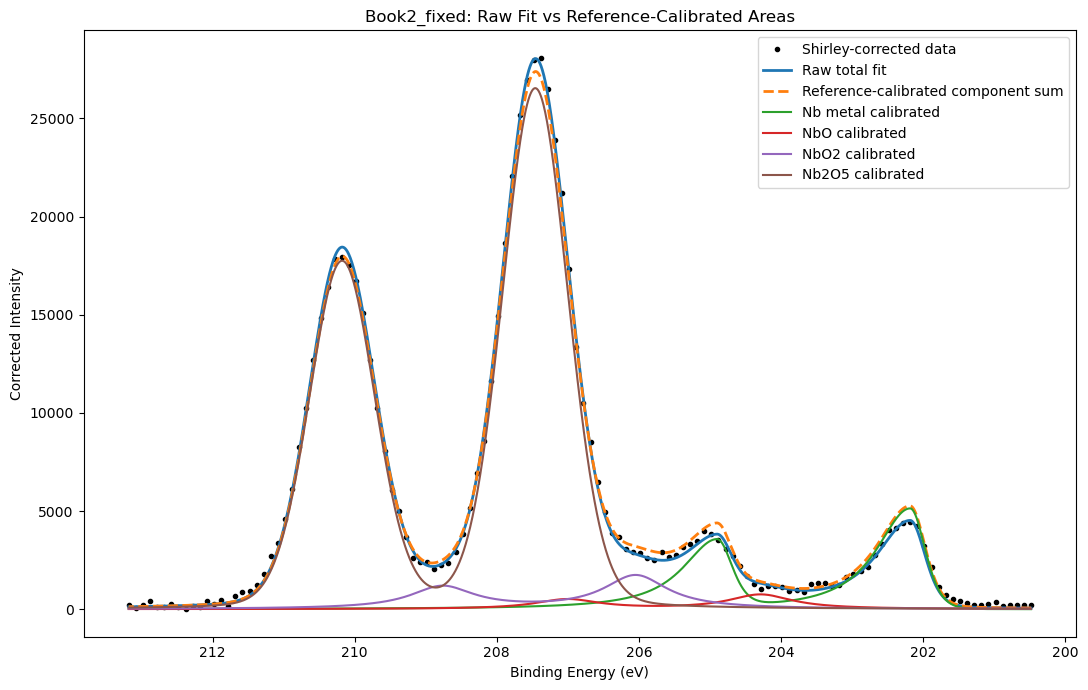

In [23]:
# Plot the fitted model and raw fitted components.
x_dense = np.linspace(SHIRLEY_MIN_BE, SHIRLEY_MAX_BE, 5000)
nb_m_dense = metal_doublet(x_dense, popt[0], popt[1], popt[2])
nbo_dense = oxide_doublet(x_dense, popt[4], popt[5], oxide_fwhm, popt[6])
nbo2_dense = oxide_doublet(x_dense, popt[7], popt[8], oxide_fwhm, popt[9])
nb2o5_dense = oxide_doublet(x_dense, popt[10], popt[11], oxide_fwhm, popt[12])
t_dense = total_model(x_dense, *popt)

plt.figure(figsize=(11, 7))
plt.plot(x, y, 'ko', markersize=3, label='Shirley-corrected data')
plt.plot(x_dense, t_dense, linewidth=2, label='Total fit')
for name, component in zip(
    component_names,
    [nb_m_dense, nbo_dense, nbo2_dense, nb2o5_dense],
):
    plt.plot(x_dense, component, linewidth=1.5, label=name)
plt.gca().invert_xaxis()
plt.xlabel('Binding Energy (eV)')
plt.ylabel('Corrected Intensity')
plt.title(f'{base_name}: Area-parameterized raw fit')
plt.legend()
plt.tight_layout()
plt.show()


In [24]:
area_results = pd.DataFrame({
    'Component': component_names,
    'Raw doublet area': raw_areas,
    '3d5/2 area': areas_5_2,
    '3d3/2 area': areas_3_2,
    'Area percent': 100.0 * raw_areas / raw_total_fit_area,
})

area_results


,Component,Raw fitted area,Calibration factor,Calibrated area,Area percent
0,Nb metal,7841.779290,1.166743,9149.341155,13.310072
1,NbO,1953.545994,1.007961,1969.099147,2.864562
2,NbO2,3760.360582,1.215410,4570.380428,6.648795
3,Nb2O5,54552.963937,0.972471,53051.161523,77.176571


In [25]:
t_fit = total_model(x, *popt)

# Ordinary residual
residuals = y - t_fit

# Poisson-normalized residual
safe_y = np.maximum(y, 1)   # avoids divide-by-zero
poisson_residuals = residuals / np.sqrt(safe_y)

residual_mean = np.mean(residuals)
residual_std = np.std(residuals)
rmse = np.sqrt(np.mean(residuals**2))

residual_std_poisson = np.sqrt(np.mean(poisson_residuals**2))

print(f"\n{base_name} FIT ERROR METRICS\n")
print(f"Residual Mean: {residual_mean:.4f}")
print(f"Residual Std Dev: {residual_std:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Poisson-normalized Residual STD: {residual_std_poisson:.4f}")


Book2_fixed FIT ERROR METRICS

Residual Mean: 16.3118
Residual Std Dev: 215.5972
RMSE: 216.2134
Poisson-normalized Residual STD: 17.4029


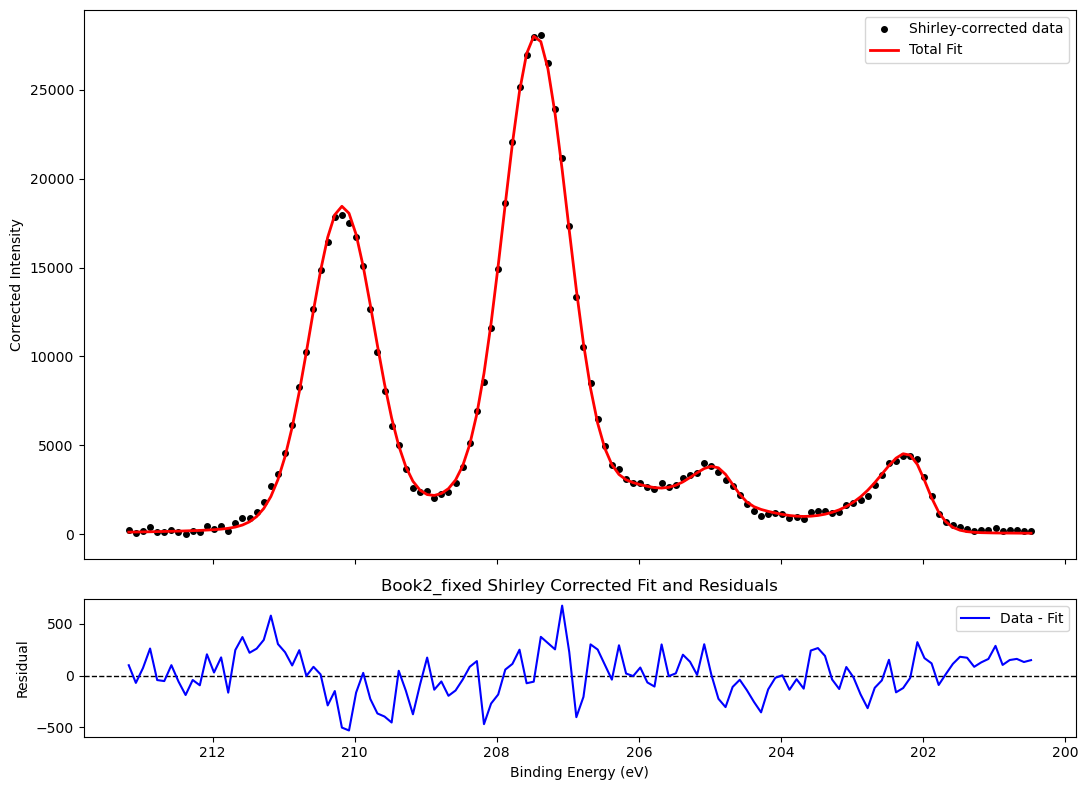

In [26]:
residuals = y - t_fit

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(11,8),
    sharex=True,
    gridspec_kw={"height_ratios":[4,1]}
)

# Main fit

ax1.plot(x, y, "ko", markersize=4, label="Shirley-corrected data")
ax1.plot(x, t_fit, "r-", linewidth=2, label="Total Fit")
ax1.set_ylabel("Corrected Intensity")
ax1.legend()

# Residuals: data - fit

ax2.axhline(0, color="black", linestyle="--", linewidth=1)
ax2.plot(x, residuals, "b-", linewidth=1.5, label="Data - Fit")
ax2.set_xlabel("Binding Energy (eV)")
ax2.set_ylabel("Residual")
ax2.legend()
ax1.invert_xaxis()
plt.title(f"{base_name} Shirley Corrected Fit and Residuals")
plt.tight_layout()
plt.show()

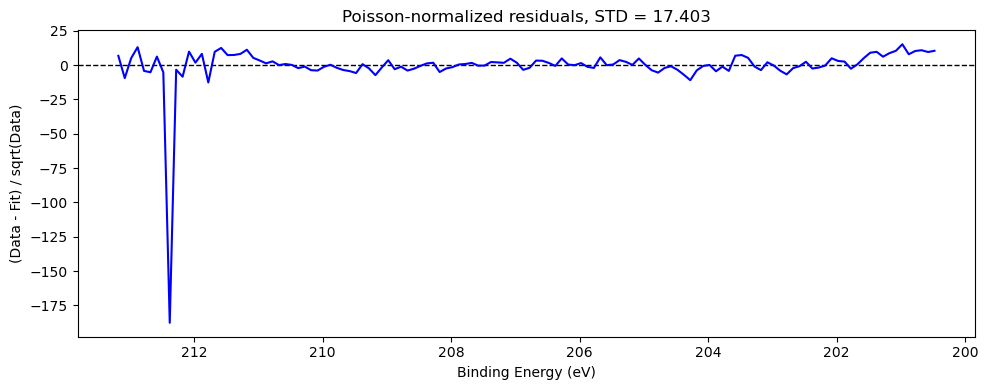

In [27]:
plt.figure(figsize=(10, 4))

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.plot(x, poisson_residuals, "b-", linewidth=1.5)

plt.gca().invert_xaxis()
plt.title(f"Poisson-normalized residuals, STD = {residual_std_poisson:.3f}")
plt.ylabel("(Data - Fit) / sqrt(Data)")
plt.xlabel("Binding Energy (eV)")
plt.tight_layout()
plt.show()

SHIFTING

In [28]:
print(f"\n{base_name} UNSHIFTED BINDING ENERGIES\n")

metal_fwhm_reported = metal_internal_to_fwhm(popt[2])
print(f"Nb metal 3d5/2: {popt[1]:.3f} eV, FWHM = {metal_fwhm_reported:.3f}")
print(f"NbO      3d5/2: {popt[5]:.3f} eV, FWHM = {oxide_fwhm:.3f}")
print(f"NbO2     3d5/2: {popt[8]:.3f} eV, FWHM = {oxide_fwhm:.3f}")
print(f"Nb2O5    3d5/2: {popt[11]:.3f} eV, FWHM = {oxide_fwhm:.3f}")

shift = 202.200 - popt[1]

metal_shifted = popt[1] + shift
nbo_shifted   = popt[5] + shift
nbo2_shifted  = popt[8] + shift
nb2o5_shifted = popt[11] + shift

print(f"\n{base_name} SHIFTED BINDING ENERGIES\n")

print(f"Nb metal 3d5/2: {metal_shifted:.3f} eV, FWHM = {metal_fwhm_reported:.3f}")
print(f"NbO      3d5/2: {nbo_shifted:.3f} eV, FWHM = {oxide_fwhm:.3f}")
print(f"NbO2     3d5/2: {nbo2_shifted:.3f} eV, FWHM = {oxide_fwhm:.3f}")
print(f"Nb2O5    3d5/2: {nb2o5_shifted:.3f} eV, FWHM = {oxide_fwhm:.3f}")

print(f"\nApplied energy shift = {shift:+.3f} eV")


Book2_fixed UNSHIFTED BINDING ENERGIES

Nb metal 3d5/2: 202.182 eV, FWHM = 0.605
NbO      3d5/2: 204.287 eV, FWHM = 1.089
NbO2     3d5/2: 206.045 eV, FWHM = 1.089
Nb2O5    3d5/2: 207.458 eV, FWHM = 1.089

Book2_fixed SHIFTED BINDING ENERGIES

Nb metal 3d5/2: 202.200 eV, FWHM = 0.605
NbO      3d5/2: 204.305 eV, FWHM = 1.089
NbO2     3d5/2: 206.063 eV, FWHM = 1.089
Nb2O5    3d5/2: 207.476 eV, FWHM = 1.089

Applied energy shift = +0.018 eV


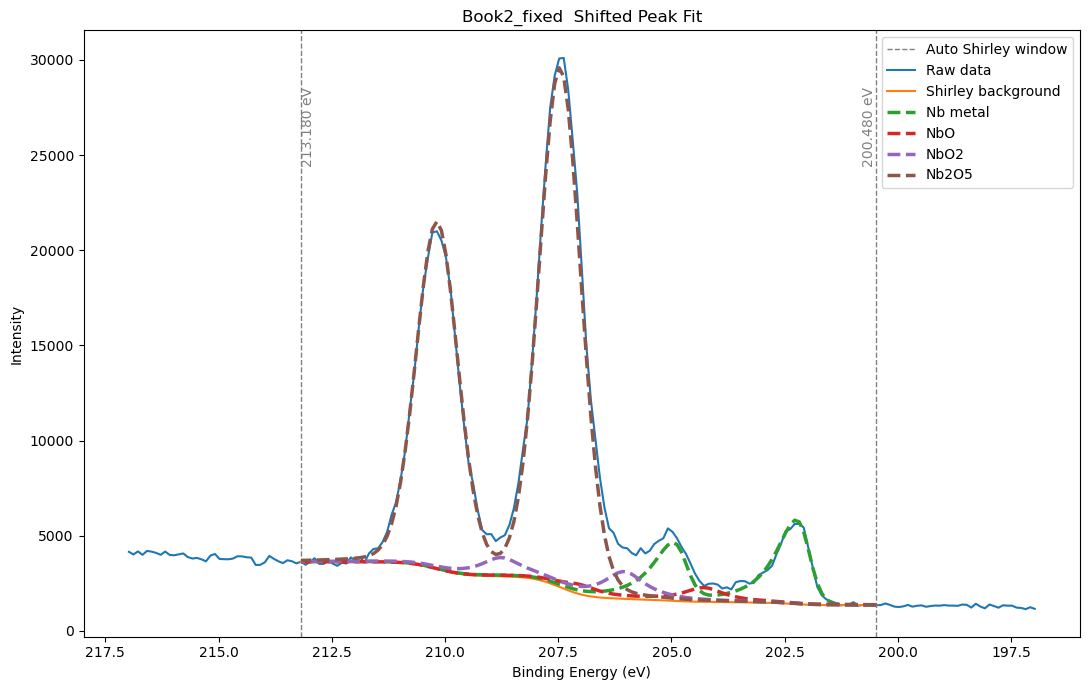

In [29]:
valid = np.isfinite(shirley)
order_bg = np.argsort(x_original[valid])

shirley_fit = np.interp(
    x,
    x_original[valid][order_bg],
    shirley[valid][order_bg]
)

plt.figure(figsize=(11, 7))

plt.axvline(SHIRLEY_MIN_BE, color="gray", linestyle="--", linewidth=1, label="Auto Shirley window")
plt.axvline(SHIRLEY_MAX_BE, color="gray", linestyle="--", linewidth=1)
plt.plot(x_original, y_original, label="Raw data", zorder=2)
plt.plot(x_original, shirley, label="Shirley background", zorder=3)

nb_m_fit_with_bg = nb_m + shirley_fit
nbo_fit_with_bg = nbo + shirley_fit
nbo2_fit_with_bg = nbo2 + shirley_fit
nb2o5_fit_with_bg = nb2o5 + shirley_fit

plt.plot(x, nb_m_fit_with_bg, "--", linewidth=2.5, label="Nb metal", zorder=4)
plt.plot(x, nbo_fit_with_bg, "--", linewidth=2.5, label="NbO", zorder=6)
plt.plot(x, nbo2_fit_with_bg, "--", linewidth=2.5, label="NbO2", zorder=6)
plt.plot(x, nb2o5_fit_with_bg, "--", linewidth=2.5, label="Nb2O5", zorder=6)

y_top = np.max(y_original)

plt.text(SHIRLEY_MIN_BE, y_top * 0.95, f"{SHIRLEY_MIN_BE:.3f} eV",
         rotation=90, va="top", ha="right", fontsize=10, color="gray")

plt.text(SHIRLEY_MAX_BE, y_top * 0.95, f"{SHIRLEY_MAX_BE:.3f} eV",
         rotation=90, va="top", ha="left", fontsize=10, color="gray")

plt.xlabel("Binding Energy (eV)")
plt.ylabel("Intensity")
plt.title(f"{base_name}  Shifted Peak Fit")
plt.gca().invert_xaxis()
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# Width diagnostic only; this factor does not alter component areas.
print('\nMETAL WIDTH DIAGNOSTIC')
print(f'Internal asymmetric-LA width: {popt[2]:.6f} eV')
print(f'FWHM reporting factor:        {METAL_FWHM_CALIBRATION:.6f}')
print(f'Reported metal FWHM:          {metal_internal_to_fwhm(popt[2]):.6f} eV')
print('\nAREA DIAGNOSTIC')
print('Component areas are direct fitted parameters and were not calibrated.')



METAL WIDTH DIAGNOSTIC
Internal asymmetric-LA width: 1.283452 eV
Calibration factor:           0.471353
Reported calibrated FWHM:     0.604959 eV
